## PCA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('../data/processed/streaming_users_clean.csv')

In [2]:
# Variables numéricas para PCA (excluyo user_id porque no es una medida sino un identificador)
features = ['age', 'monthly_watch_time_mins', 'customer_support_tickets', 'dias_desde_login']
X = df[features].dropna()   # descarto las 472 filas sin dias_desde_login

In [3]:
# Confirmo que las varianzas son distintas (por eso el escalado es obligatorio)
print("Varianza sin escalar:")
print(X.var().round(1))
print(f"\nFilas usadas: {len(X)} de {len(df)}")

Varianza sin escalar:
age                            131.4
monthly_watch_time_mins     241826.0
customer_support_tickets         0.7
dias_desde_login            714352.2
dtype: float64

Filas usadas: 7528 de 8000


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Las varianzas sin escalar van de 0.7 (tickets) a 714.352 (dias_desde_login).
Sin estandarizar, el PCA confundiría "mayor escala" con "mayor relevancia" y las dos variables de unidad grande dominarían los componentes por magnitud. Por eso aplico StandardScaler (media 0, desvío 1) antes del PCA.

In [5]:
pca_full = PCA()
pca_full.fit(X_scaled)

varianza = pca_full.explained_variance_ratio_
acumulada = 0
for i in range(len(varianza)):
    acumulada += varianza[i]
    print(f"PC{i+1}: {varianza[i]*100:.2f}% | Acumulada: {acumulada*100:.2f}%")

PC1: 25.51% | Acumulada: 25.51%
PC2: 25.03% | Acumulada: 50.54%
PC3: 24.86% | Acumulada: 75.40%
PC4: 24.60% | Acumulada: 100.00%


Las cuatro componentes explican una proporción casi idéntica de la varianza. 
Esta uniformidad indica que las variables numéricas son estadísticamente independientes: no hay redundancia que el PCA pueda aprovechar para resumirlas.

**El PCA no logra reducir la dimensionalidad en este dataset**, y confirma la falta de correlaciones observada en el EDA.

#### Se distinguen perfiles al proyectar y colorear por plan?

In [6]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'])
df_pca['plan'] = df.loc[X.index, 'subscription_plan'].values   # realineo por índice

loadings = pd.DataFrame(pca_2d.components_.T, index=features, columns=['PC1','PC2'])
print(loadings.round(3))

                            PC1    PC2
age                       0.636  0.170
monthly_watch_time_mins   0.441 -0.299
customer_support_tickets  0.181  0.910
dias_desde_login         -0.607  0.232


PC2 está dominada casi por completo por customer_support_tickets (0.91): representaría el eje de contacto con soporte. 

PC1 combina age (+0.64) y watch_time (+0.44) contra dias_desde_login (−0.61), interpretable tentativamente como un eje de actividad. 

**Aclaración:** como las variables están poco correlacionadas, estos componentes son una rotación ortogonal casi arbitraria —el "significado" es frágil y específico de este dataset y escalado; no tienen nombre propio.

#### Proyección visual

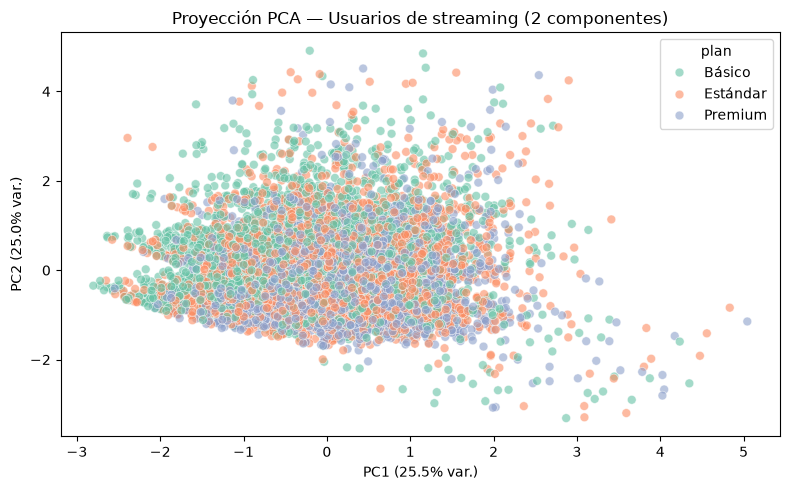

In [8]:

plt.figure(figsize=(8,5))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='plan',
                hue_order=['Básico','Estándar','Premium'], palette='Set2', s=40, alpha=0.6)
plt.title('Proyección PCA — Usuarios de streaming (2 componentes)')
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var.)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var.)")
plt.tight_layout()

plt.savefig('../reports/figuras/pca_proyeccion.png', dpi=150, bbox_inches='tight')
plt.show()

Al proyectar sobre las dos primeras componentes y colorear por plan, los tres grupos se superponen sin formar clústeres: no se distinguen perfiles de usuario separables. 
Es coherente con el resto del análisis: como las variables numéricas son independientes y el plan solo se asocia con el consumo, no existe una combinación de variables que agrupe a los usuarios en perfiles diferenciados.
El PCA más que revelar estructura, confirma su ausencia.